<a href="https://colab.research.google.com/github/longvujulix/Data-Project/blob/main/Preprocess_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-processing:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Tạo mảng dữ liệu 2D (500 x 5)
np.random.seed(777)

customer_id = np.random.randint(1, 51, 500)
product_id  = np.random.randint(100, 151, 500)
quantity    = np.random.randint(1, 21, 500)
price       = np.random.randint(50, 501, 500)
region_id   = np.random.randint(1, 6, 500)

data = np.column_stack([customer_id, product_id, quantity, price, region_id])

print("Mảng dữ liệu (5 dòng đầu):")
print(data[:5])

Mảng dữ liệu (5 dòng đầu):
[[ 40 112   5 463   3]
 [ 48 145   1 130   2]
 [ 39 115   2 445   2]
 [ 24 150   2 184   4]
 [ 50 145  17 154   2]]


In [ ]:
# 2. Tổng số lượng sản phẩm tất cả khách hàng đã mua
total_quantity_all = np.sum(data[:, 2])
print("Tổng số lượng sản phẩm tất cả khách hàng đã mua:", total_quantity_all)

Tổng số lượng sản phẩm tất cả khách hàng đã mua: 5328


In [ ]:
# 3. Khách hàng có id = 40 mua bao nhiêu sản phẩm
qty_customer_40 = np.sum(data[data[:, 0] == 40][:, 2])
print("Tổng số lượng sản phẩm khách hàng có id 40 đã mua:", qty_customer_40)

Tổng số lượng sản phẩm khách hàng có id 40 đã mua: 89


In [ ]:
# 4. Bảng tổng hợp
unique_products = np.unique(data[:, 1])

summary = []

for pid in unique_products:
    mask = data[:, 1] == pid
    total_q = np.sum(data[mask][:, 2])
    avg_p = np.mean(data[mask][:, 3])
    summary.append([pid, total_q, avg_p])

summary = np.array(summary)

print("Bảng tổng hợp summary:")
print(summary[:10])

Bảng tổng hợp summary:
[[100.          71.         381.        ]
 [101.          95.         287.36363636]
 [102.         108.         251.33333333]
 [103.         127.         285.11111111]
 [104.         124.         265.71428571]
 [105.          73.         243.83333333]
 [106.          87.         288.5       ]
 [107.         148.         274.91666667]
 [108.          86.         334.44444444]
 [109.          80.         252.4       ]]


# Xử lý dữ liệu và trực quan hoá

In [ ]:
sns.set(style="whitegrid")

# 1. Đọc dữ liệu & xem thông tin chung
df = pd.read_csv("sales.csv")

print("Shape:", df.shape)

print("\n--- HEAD ---")
display(df.head())

print("\n--- TAIL ---")
display(df.tail())

print("\n--- INFO ---")
df.info()

print("\n--- DESCRIBE (numeric) ---")
display(df.describe())

print("\n--- DESCRIBE (include all) ---")
display(df.describe(include="all"))

Shape: (4000, 9)

--- HEAD ---


,transaction_id,customer_id,product_id,category,transaction_date,quantity,price,discount,cost
0,1,CUST_0366,PROD_092,Electronics,01-12-23,4.0,499.45,0.17,220.05
1,2,CUST_0383,PROD_063,Home,21-07-24,1.0,436.29,0.24,54.36
2,3,CUST_0323,PROD_093,Clothing,14-03-24,2.0,417.75,0.06,310.37
3,4,CUST_0477,PROD_127,Electronics,25-08-24,2.0,227.10,0.06,33.63
4,5,CUST_0099,PROD_158,Sports,03-09-22,3.0,412.28,0.01,74.83



--- TAIL ---


,transaction_id,customer_id,product_id,category,transaction_date,quantity,price,discount,cost
3995,3996,CUST_0095,PROD_174,Sports,29-11-22,6.0,354.15,1.314738,39.09
3996,3997,CUST_0296,PROD_042,Sports,17-05-22,9.0,382.54,0.050000,139.48
3997,3998,CUST_0298,PROD_042,Home,03-07-24,3.0,453.65,0.110000,94.94
3998,3999,CUST_0181,PROD_173,Grocery,21-10-23,3.0,372.18,0.230000,317.12
3999,4000,CUST_0301,PROD_045,Sports,31-08-22,9.0,192.13,0.110000,25.20



--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    4000 non-null   int64  
 1   customer_id       4000 non-null   object 
 2   product_id        4000 non-null   object 
 3   category          4000 non-null   object 
 4   transaction_date  4000 non-null   object 
 5   quantity          3850 non-null   float64
 6   price             3850 non-null   float64
 7   discount          3854 non-null   float64
 8   cost              3850 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 281.4+ KB

--- DESCRIBE (numeric) ---


,transaction_id,quantity,price,discount,cost
count,4000.000000,3850.000000,3850.000000,3854.000000,3850.000000
mean,2000.500000,4.850649,246.336642,0.179369,176.474047
std,1154.844867,2.820937,152.533274,0.226680,101.069724
min,1.000000,-9.000000,-477.940000,0.000000,3.010000
25%,1000.750000,3.000000,125.350000,0.080000,88.557500
50%,2000.500000,5.000000,249.880000,0.150000,176.550000
75%,3000.250000,7.000000,374.015000,0.230000,264.927500
max,4000.000000,9.000000,499.910000,1.994710,349.900000



--- DESCRIBE (include all) ---


,transaction_id,customer_id,product_id,category,transaction_date,quantity,price,discount,cost
count,4000.000000,4000,4000,4000,4000,3850.000000,3850.000000,3854.000000,3850.000000
unique,NaN,500,200,5,1065,NaN,NaN,NaN,NaN
top,NaN,CUST_0154,PROD_074,Sports,21-04-22,NaN,NaN,NaN,NaN
freq,NaN,17,35,834,11,NaN,NaN,NaN,NaN
mean,2000.500000,NaN,NaN,NaN,NaN,4.850649,246.336642,0.179369,176.474047
std,1154.844867,NaN,NaN,NaN,NaN,2.820937,152.533274,0.226680,101.069724
min,1.000000,NaN,NaN,NaN,NaN,-9.000000,-477.940000,0.000000,3.010000
25%,1000.750000,NaN,NaN,NaN,NaN,3.000000,125.350000,0.080000,88.557500
50%,2000.500000,NaN,NaN,NaN,NaN,5.000000,249.880000,0.150000,176.550000
75%,3000.250000,NaN,NaN,NaN,NaN,7.000000,374.015000,0.230000,264.927500


In [ ]:
# 2. Đổi kiểu dữ liệu của cột 'transaction_date' sang datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

df['transaction_date'].head()

0   2023-01-12
1   2024-07-21
2   2024-03-14
3   2024-08-25
4   2022-03-09
Name: transaction_date, dtype: datetime64[ns]

In [ ]:
# 3. Chuyển price, quantity âm thành giá trị tuyệt đối
df['price'] = df['price'].abs()
df['quantity'] = df['quantity'].abs()

print("Giá trị âm ở price:", (df['price'] < 0).sum())
print("Giá trị âm ở quantity:", (df['quantity'] < 0).sum())

Giá trị âm ở price: 0
Giá trị âm ở quantity: 0


In [ ]:
# 4. Xử lý discount bất thường
df['discount'] = df['discount'].clip(lower=0, upper=1)

print("Discount < 0:", (df['discount'] < 0).sum())
print("Discount > 1:", (df['discount'] > 1).sum())

Discount < 0: 0
Discount > 1: 0


In [ ]:
# 5. Đếm giá trị NaN của các cột
print("Số NaN mỗi cột:")
print(df.isna().sum())

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("\nSau khi fill median, NaN mỗi cột:")
print(df.isna().sum())

Số NaN mỗi cột:
transaction_id        0
customer_id           0
product_id            0
category              0
transaction_date      0
quantity            150
price               150
discount            146
cost                150
dtype: int64

Sau khi fill median, NaN mỗi cột:
transaction_id      0
customer_id         0
product_id          0
category            0
transaction_date    0
quantity            0
price               0
discount            0
cost                0
dtype: int64


In [ ]:
# 6. Thêm cột month_num, month, final_amount
df['month_num'] = df['transaction_date'].dt.month
df['month'] = df['transaction_date'].dt.month_name()

df['final_amount'] = df['quantity'] * df['price'] * (1 - df['discount'])

df.head()

,transaction_id,customer_id,product_id,category,transaction_date,quantity,price,discount,cost,month_num,month,final_amount
0,1,CUST_0366,PROD_092,Electronics,2023-01-12,4.0,499.45,0.17,220.05,1,January,1658.1740
1,2,CUST_0383,PROD_063,Home,2024-07-21,1.0,436.29,0.24,54.36,7,July,331.5804
2,3,CUST_0323,PROD_093,Clothing,2024-03-14,2.0,417.75,0.06,310.37,3,March,785.3700
3,4,CUST_0477,PROD_127,Electronics,2024-08-25,2.0,227.10,0.06,33.63,8,August,426.9480
4,5,CUST_0099,PROD_158,Sports,2022-03-09,3.0,412.28,0.01,74.83,3,March,1224.4716


In [ ]:
# 7. Khách hàng có tổng chi tiêu lớn nhất
customer_spend = df.groupby('customer_id')['final_amount'].sum()
top_customer_id = customer_spend.idxmax()
top_customer_spent = customer_spend.max()

print("Top customer:", top_customer_id)
print("Total:", top_customer_spent)

# Sản phẩm mà khách này mua nhiều nhất (theo quantity)
df_top_cust = df[df['customer_id'] == top_customer_id]
prod_qty = df_top_cust.groupby('product_id')['quantity'].sum()
top_product_id = prod_qty.idxmax()

print("Favorite product of top customer:", top_product_id)

Top customer: CUST_0341
Total: 23249.2948
Favorite product of top customer: PROD_017


In [ ]:
# 8. Sản phẩm doanh thu cao nhất trong mỗi category
product_rev = df.groupby(['category', 'product_id'])['final_amount'].sum().reset_index()

idx = product_rev.groupby('category')['final_amount'].idxmax()
top_products_each_cat = product_rev.loc[idx].reset_index(drop=True)

print("Sản phẩm doanh thu cao nhất trong từng category:")
display(top_products_each_cat)

Sản phẩm doanh thu cao nhất trong từng category:


,category,product_id,final_amount
0,Clothing,PROD_158,15853.89550
1,Electronics,PROD_051,14386.05710
2,Grocery,PROD_017,13837.71940
3,Home,PROD_191,13024.81495
4,Sports,PROD_124,16337.68930


In [ ]:
# 9. Phát hiện chi tiêu bất thường theo customer_id (dùng IQR)
customer_spend = df.groupby('customer_id')['final_amount'].sum().reset_index()
customer_spend.rename(columns={'final_amount': 'total_spent'}, inplace=True)

Q1 = customer_spend['total_spent'].quantile(0.25)
Q3 = customer_spend['total_spent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = customer_spend[(customer_spend['total_spent'] < lower_bound) |
                          (customer_spend['total_spent'] > upper_bound)]

outliers_top3 = outliers.sort_values('total_spent', ascending=False).head(3)

print("3 khách hàng có chi tiêu bất thường theo IQR:")
display(outliers_top3)

3 khách hàng có chi tiêu bất thường theo IQR:


,customer_id,total_spent
340,CUST_0341,23249.2948
398,CUST_0399,20391.6166
39,CUST_0040,19269.4839


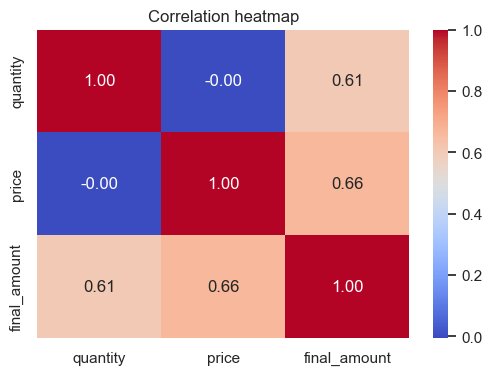

In [ ]:
# 10. Vẽ heatmap tương quan
cols_corr = ['quantity', 'price', 'final_amount']
corr_mat = df[cols_corr].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

### Nhận xét:
- final_amount có tương quan dương khá mạnh với quantity (0.61) và price (0.66), đúng với công thức tính doanh thu.
- quantity và price hầu như không tương quan (~0), cho thấy giá sản phẩm không ảnh hưởng đến số lượng mua trong dữ liệu.
- price có mức ảnh hưởng đến final_amount nhỉnh hơn một chút so với quantity.

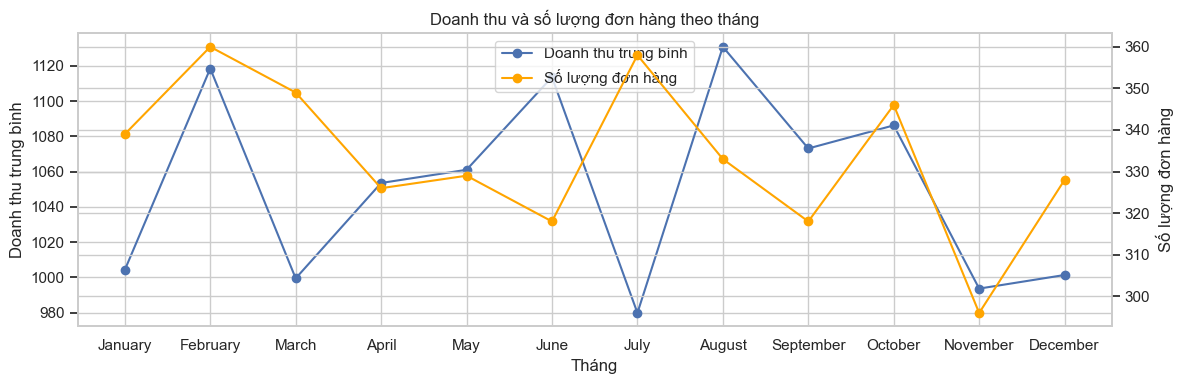

In [ ]:
# 11. Doanh thu trung bình và số đơn hàng theo tháng

# Tính doanh thu trung bình và số đơn hàng theo tháng
monthly = (
    df.groupby(['month_num', 'month'])
      .agg(
          avg_revenue=('final_amount', 'mean'),
          order_count=('final_amount', 'count')
      )
      .reset_index()
      .sort_values('month_num')
)

# Lấy tên tháng (dùng làm nhãn trục X)
months = monthly['month']

fig, ax1 = plt.subplots(figsize=(12, 4))

# Đường 1: Doanh thu trung bình (trục trái)
line1, = ax1.plot(
    months,
    monthly['avg_revenue'],
    marker='o',
    label='Doanh thu trung bình'
)
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Doanh thu trung bình')
ax1.tick_params(axis='y')

# Đường 2: Số lượng đơn hàng (trục phải)
ax2 = ax1.twinx()
line2, = ax2.plot(
    months,
    monthly['order_count'],
    marker='o',
    color='orange',
    label='Số lượng đơn hàng'
)
ax2.set_ylabel('Số lượng đơn hàng')
ax2.tick_params(axis='y')

# Title
plt.title('Doanh thu và số lượng đơn hàng theo tháng')

# Gộp legend của 2 trục
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.tight_layout()
plt.show()

### Nhận xét
- Doanh thu trung bình và số lượng đơn hàng đều biến động mạnh theo tháng, không ổn định.
- Một số tháng như February, August, October có mức doanh thu trung bình và số đơn hàng đều cao hơn rõ rệt.
- Các tháng July và November ghi nhận mức thấp nhất ở cả doanh thu trung bình và số lượng đơn hàng.
- Hai đường xu hướng nhìn chung khá tương đồng, cho thấy số lượng đơn hàng nhiều thường kéo theo doanh thu trung bình cao hơn.

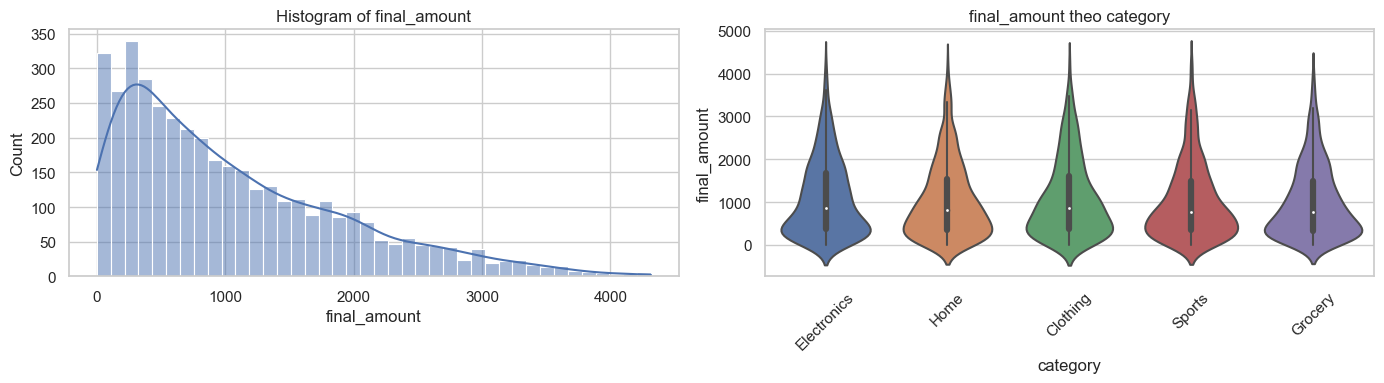

In [ ]:
# 12. Vẽ biểu đồ Phân bố final_amount; biểu đồ violinplot cho final_amount theo category như gợi ý và nhận xét
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ---- Biểu đồ 1: Histogram final_amount ----
sns.histplot(
    data=df,
    x='final_amount',
    kde=True,
    bins=40,
    ax=axes[0]
)
axes[0].set_title("Histogram of final_amount")
axes[0].set_xlabel("final_amount")
axes[0].set_ylabel("Count")

# ---- Biểu đồ 2: Violinplot theo category ----
sns.violinplot(
    data=df,
    x='category',
    y='final_amount',
    ax=axes[1]
)
axes[1].set_title("final_amount theo category")
axes[1].set_xlabel("category")
axes[1].set_ylabel("final_amount")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Nhận xét:
- Histogram: final_amount lệch phải mạnh, đa số đơn hàng giá trị thấp; các giá trị lớn xuất hiện ít.
- Violinplot: Electronics và Home có giá trị đơn hàng cao hơn và phân bố rộng hơn; Grocery và Clothing chủ yếu ở mức thấp.

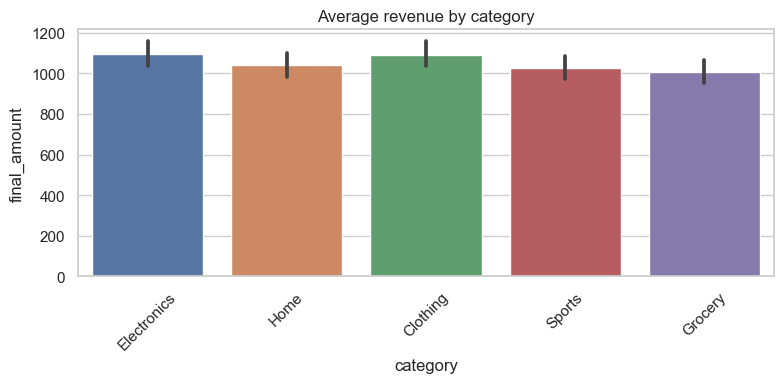

In [ ]:
# 13. Vẽ biểu đồ thể hiện trung bình doanh thu theo category như gợi ý và nhận xét.
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='category', y='final_amount', estimator='mean')

plt.title("Average revenue by category")
plt.xlabel("category")
plt.ylabel("final_amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Nhận xét:
- Electronics và Clothing có doanh thu trung bình cao hơn các nhóm còn lại.
- Grocery và Sports có mức trung bình thấp nhất.
- Chênh lệch giữa các category không quá lớn, nhưng vẫn cho thấy hành vi chi tiêu thay đổi theo loại sản phẩm.

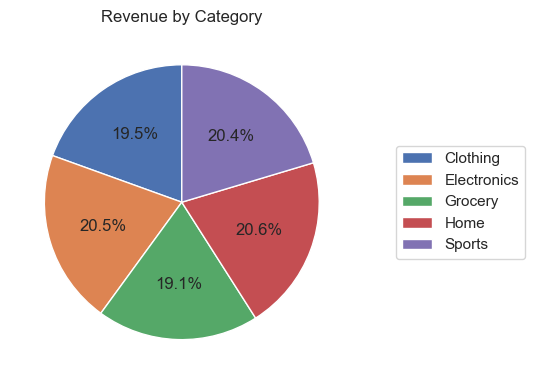

In [ ]:
# 14. Vẽ biểu đồ thể hiện tỷ lệ doanh thu theo loại sản phẩm như gợi ý. Sau đó nhận xét về biểu đồ
cat_rev = df.groupby('category')['final_amount'].sum().reset_index()


plt.figure(figsize=(10, 4))

# Pie chart
plt.pie(
    cat_rev['final_amount'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90
)

plt.legend(
    cat_rev['category'],
    loc='center left',
    bbox_to_anchor=(1.1, 0.5)
)

plt.title("Revenue by Category")
plt.tight_layout()
plt.show()



### Nhận xét:
- Electronics chiếm tỷ trọng doanh thu lớn nhất, cho thấy nhóm sản phẩm này đóng góp nhiều nhất vào tổng doanh thu.
- Grocery và Sports có tỷ lệ thấp hơn, phản ánh giá trị giao dịch nhỏ hoặc tần suất mua ít hơn.
- Tỷ lệ doanh thu phân bổ khá chênh lệch giữa các category, gợi ý mức độ quan trọng khác nhau của từng nhóm sản phẩm.

# Trực quan hóa dữ liệu bản đồ

In [ ]:
# 1. Đọc dữ liệu
df = pd.read_csv("world_happiness.csv")

print("=== HEAD ===")
display(df.head())

print("=== TAIL ===")
display(df.tail())

print("=== INFO ===")
df.info()

print("=== DESCRIBE ===")
display(df.describe(include="all"))

=== HEAD ===


,Unnamed: 0,Data
0,0,Switzerland_Western Europe_7.587
1,1,Iceland_Western Europe_7.561
2,2,Denmark_Western Europe_7.527
3,3,Norway_Western Europe_7.522
4,4,Canada_North America_7.427


=== TAIL ===


,Unnamed: 0,Data
153,153,Rwanda_Sub-Saharan Africa_3.465
154,154,Benin_Sub-Saharan Africa_3.34
155,155,Syria_Middle East and Northern Africa_3.006
156,156,Burundi_Sub-Saharan Africa_2.905
157,157,Togo_Sub-Saharan Africa_2.839


=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  158 non-null    int64 
 1   Data        158 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.6+ KB
=== DESCRIBE ===


,Unnamed: 0,Data
count,158.000000,158
unique,NaN,158
top,NaN,Switzerland_Western Europe_7.587
freq,NaN,1
mean,78.500000,NaN
std,45.754781,NaN
min,0.000000,NaN
25%,39.250000,NaN
50%,78.500000,NaN
75%,117.750000,NaN


In [ ]:
# 2. Tách cột Data thành 3 cột
df[['Country', 'Region', 'Happiness Score']] = df['Data'].str.split('_', expand=True)

df.head()

,Unnamed: 0,Data,Country,Region,Happiness Score
0,0,Switzerland_Western Europe_7.587,Switzerland,Western Europe,7.587
1,1,Iceland_Western Europe_7.561,Iceland,Western Europe,7.561
2,2,Denmark_Western Europe_7.527,Denmark,Western Europe,7.527
3,3,Norway_Western Europe_7.522,Norway,Western Europe,7.522
4,4,Canada_North America_7.427,Canada,North America,7.427


In [ ]:
# 3. Chuyển sang float
df['Happiness Score'] = df['Happiness Score'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       158 non-null    int64  
 1   Data             158 non-null    object 
 2   Country          158 non-null    object 
 3   Region           158 non-null    object 
 4   Happiness Score  158 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 6.3+ KB


In [ ]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="Happiness Score",
    color_continuous_scale="OrRd",
    range_color=(df['Happiness Score'].min(), df['Happiness Score'].max()),
    title="World Happiness Score Map",
)

fig.show()